# MAKE A COPY DULU YAA GUYSS

# Import Data & Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [ ]:
!wget "https://raw.githubusercontent.com/Ditt-A/GDGoC-StudyJamML2/main/data/titanic/train.csv"

--2026-02-10 12:25:47--  https://raw.githubusercontent.com/Ditt-A/GDGoC-StudyJamML2/main/data/titanic/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61194 (60K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  59.76K  --.-KB/s    in 0.007s  

2026-02-10 12:25:47 (8.69 MB/s) - ‘train.csv’ saved [61194/61194]



# Data Overview

In [ ]:
# Import data
df = pd.read_csv("train.csv")

In [ ]:
# data berikan saya info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# berapa banyak sih datanya?
df.shape

(891, 12)

In [ ]:
# Melihat 5 data teratas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Statistik datanya
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# jumlah missing value per fitur
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).head(10)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


# Pre-processing Stage 1

## Handling Missing Value

### Option A - SimpleImputer

In [ ]:
df_num = df.copy()

num_cols = ["Age", "Fare", "SibSp", "Parch"]
print(df_num[num_cols].isna().sum())

Age      177
Fare       0
SibSp      0
Parch      0
dtype: int64


In [ ]:
num_imputer = SimpleImputer(strategy="median")
df_num[num_cols] = num_imputer.fit_transform(df_num[num_cols])

df_num[num_cols].isna().sum()

,0
Age,0
Fare,0
SibSp,0
Parch,0


In [ ]:
df_cat = df.copy()

cat_cols = ["Embarked", "Cabin", "Sex"]
for c in cat_cols:
    print("\n", c)
    print(df_cat[c].value_counts(dropna=False).head(10))


 Embarked
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

 Cabin
Cabin
NaN            687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
D                3
E101             3
C22 C26          3
F33              3
C83              2
Name: count, dtype: int64

 Sex
Sex
male      577
female    314
Name: count, dtype: int64


In [ ]:
mf_imputer = SimpleImputer(strategy="most_frequent")
df_cat[["Embarked", "Sex"]] = mf_imputer.fit_transform(df_cat[["Embarked", "Sex"]])

cabin_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
df_cat[["Cabin"]] = cabin_imputer.fit_transform(df_cat[["Cabin"]])

df_cat[cat_cols].isna().sum()

,0
Embarked,0
Cabin,0
Sex,0


### Option B - Groupby

In [ ]:
df_num2 = df.copy()

age_median_by_pclass = df_num2.groupby("Pclass")["Age"].transform("median")
df_num2["Age"] = df_num2["Age"].fillna(age_median_by_pclass)

df_num2[["Age"]].isna().sum()

,0
Age,0


In [ ]:
df_cat2 = df.copy()

df_cat2["Embarked"] = df_cat2["Embarked"].fillna(
    df_cat2.groupby("Pclass")["Embarked"].transform(lambda x: x.mode().iloc[0])
)

df_cat2["Cabin"] = df_cat2["Cabin"].fillna("Unknown")
df_cat2[["Embarked","Cabin"]].isna().sum()

,0
Embarked,0
Cabin,0


### Handling Missing Values (Groupby Imputation)
Di tahap ini kita mengisi nilai yang hilang (**missing values**) menggunakan pendekatan **by-group** agar lebih masuk akal secara konteks.

**Kenapa pakai groupby?**
Karena nilai sebuah kolom bisa berbeda tergantung kelompoknya.  
Contoh Titanic: umur (`Age`) penumpang kelas 1 bisa berbeda distribusinya dengan kelas 3.

**Yang kita lakukan:**
- `Age` → isi dengan **median Age per Pclass**
- `Embarked` → isi dengan **mode Embarked per Pclass**
- `Cabin` → isi dengan `"Unknown"` (missing Cabin sangat banyak dan missing itu sendiri bisa jadi informasi)

**Output yang diharapkan:**
- Kolom `Age`, `Embarked`, `Cabin` tidak memiliki NaN (atau jauh berkurang)
- Imputasi lebih “realistis” dibanding mean/median global

In [ ]:
df[num_cols] = df_num2[num_cols]
df[cat_cols] = df_cat2[cat_cols]

## Handling Duplicates Value

In [ ]:
print("Full-row duplicates:", df.duplicated().sum())

Full-row duplicates: 0


In [ ]:
subset_key = ["Name", "Ticket", "Fare"]
print("Duplicates by subset:", df.duplicated(subset=subset_key).sum())

Duplicates by subset: 0


In [ ]:
df = df.drop_duplicates()
print("After drop_duplicates:", df.shape)

After drop_duplicates: (891, 12)


### Handling Duplicated Data
Duplikasi data bisa membuat analisis bias dan membuat model “belajar” dari data yang sama berulang-ulang.

**Yang kita lakukan:**
- Cek apakah ada baris duplikat (`duplicated().sum()`)
- Jika ada, kita buang duplikat (`drop_duplicates()`)

**Catatan penting:**
- Untuk dataset real, kita juga bisa cek duplikasi berdasarkan subset kolom tertentu (mis. user_id + timestamp)

**Output yang diharapkan:**
- Jumlah duplikat menjadi 0
- Ukuran dataset bisa sedikit berkurang (kalau memang ada duplikat)


## Fixing Data Types

In [ ]:
print("Before:")
print(df.dtypes)

Before:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
to_num = ["Age", "Fare", "SibSp", "Parch", "Pclass", "Survived"]
for col in to_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
df["Name"] = df["Name"].astype("str").str.strip().str.lower()
df["Sex"] = df["Sex"].astype("str").str.strip().str.lower().astype("category")
df["Embarked"] = df["Embarked"].astype("str").str.strip().str.upper().astype("category")
df["Ticket"] = df["Ticket"].astype("str").str.strip().str.lower().astype("category")
df["Cabin"] = df["Cabin"].astype("str").str.strip().str.upper().astype("category")

In [ ]:
print("\nAfter:")
print(df.dtypes)


After:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket         category
Fare            float64
Cabin          category
Embarked       category
dtype: object


### Correct Data Types (Cek tipe data)
Tipe data yang salah bisa membuat EDA/ML error atau menghasilkan insight yang keliru.

**Contoh masalah:**
- Kolom angka terbaca sebagai teks (object/string)
- Kolom kategori terbaca sebagai angka padahal label

**Yang kita lakukan:**
- Cek tipe data dengan `df_clean.info()` atau `df_clean.dtypes`

**Output yang diharapkan:**
- Kolom numerik terbaca sebagai `int`/`float`
- Kolom kategorikal terbaca sebagai `object/string` atau `category`


## Categorical Value Consistency

In [ ]:
print("Before cleaning:")
print(df["Sex"].value_counts(dropna=False).head(10))
print(df["Embarked"].value_counts(dropna=False).head(10))

Before cleaning:
Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [ ]:
df["Sex"] = df["Sex"].astype("string").str.strip().str.lower()
df["Embarked"] = df["Embarked"].astype("string").str.strip().str.upper()

In [ ]:
print("\nAfter cleaning:")
print(df["Sex"].value_counts(dropna=False).head(10))
print(df["Embarked"].value_counts(dropna=False).head(10))


After cleaning:
Sex
male      577
female    314
Name: count, dtype: Int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: Int64


### Categorical Value Consistent (Standarisasi Kategori)
Kategori sering “pecah” karena perbedaan penulisan:
- spasi: `" Male"` vs `"Male"`
- huruf besar-kecil: `"FEMALE"` vs `"female"`

**Kenapa penting?**
Kalau tidak konsisten:
- EDA bisa salah (kategori terlihat lebih banyak)
- One-hot encoding menghasilkan kolom ekstra (noise)
- Model belajar pola yang salah

**Yang kita lakukan:**
- `Sex`: trim spasi + lower-case
- `Embarked`: trim spasi + upper-case

**Output yang diharapkan:**
- Label kategori menjadi seragam
- `value_counts()` menunjukkan kategori yang “bersih” dan tidak terpecah


# Exploratory Data Analysis (EDA)

## Univariate - Numerikal

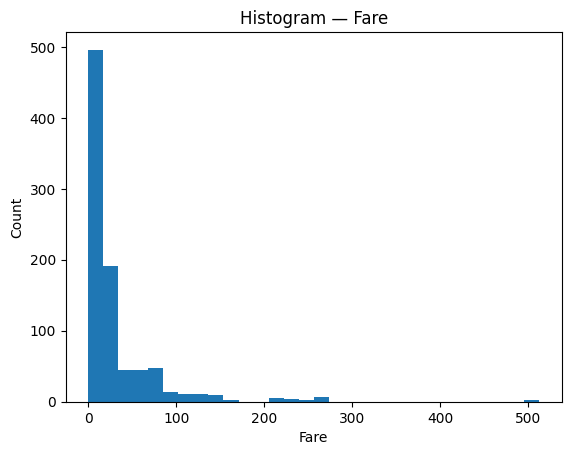

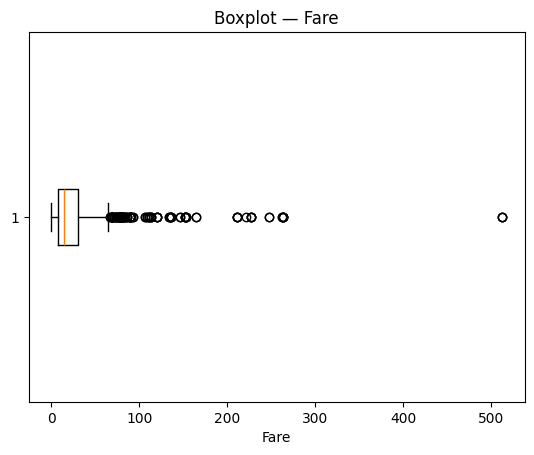

In [ ]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]

# Histogram: Fare
plt.figure()
plt.hist(df["Fare"].dropna(), bins=30)
plt.title("Histogram — Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

# Boxplot: Fare
plt.figure()
plt.boxplot(df["Fare"].dropna(), vert=False)
plt.title("Boxplot — Fare")
plt.xlabel("Fare")
plt.show()

### Fare — Histogram & Boxplot
**Apa yang terlihat dari grafik:**
- Distribusi `Fare` **sangat skew ke kanan** (kebanyakan nilai kecil, ekor panjang ke nilai besar).
- Boxplot menunjukkan banyak outlier di sisi kanan, termasuk nilai ekstrem (hingga > 500).

**Interpretasi singkat:**
- Nilai `Fare` ekstrem kemungkinan **valid** (tiket kelas 1 / suite), bukan data error.
- Namun, karena distribusi heavy-tail, `Fare` bisa:
  - mendominasi model tertentu,
  - membuat statistik (mean) “tertarik”,
  - dan menyulitkan model menangkap pola mayoritas data.

✅ **Keputusan Preprocessing Tahap 2:**
- Terapkan **Skewness Fix**:
  - **`Fare_log = log1p(Fare)`** untuk mengurangi efek heavy-tail dan membuat distribusi lebih stabil.
- Pertimbangkan **Outlier Handling** jika masih terlalu ekstrem setelah log:
  - **Winsorize/Cap p99** (nilai di atas p99 disamakan ke p99), terutama jika ingin menjaga semua baris tanpa drop.
- Saat scaling numerik:
  - Jika outlier masih terasa → gunakan **RobustScaler** (lebih tahan outlier).


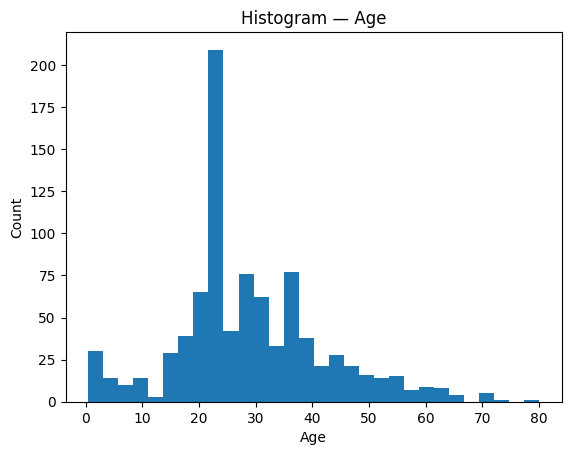

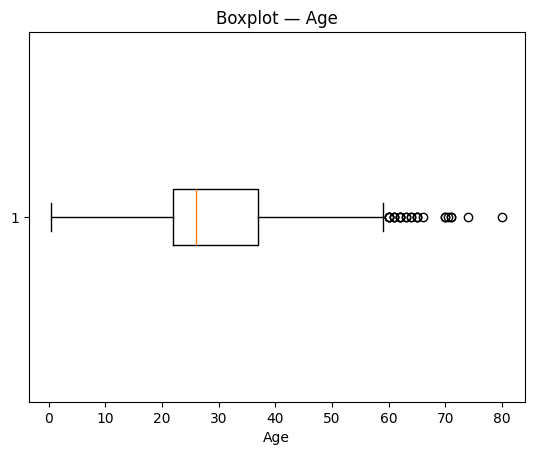

In [ ]:
# Histogram: Age
plt.figure()
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Histogram — Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Boxplot: Age
plt.figure()
plt.boxplot(df["Age"].dropna(), vert=False)
plt.title("Boxplot — Age")
plt.xlabel("Age")
plt.show()

### Age — Histogram & Boxplot
**Apa yang terlihat dari grafik:**
- Distribusi `Age` terkonsentrasi di rentang dewasa muda (sekitar 20–40).
- Boxplot menunjukkan beberapa nilai tinggi (sekitar 60–80) yang muncul sebagai *outlier*.

**Interpretasi singkat:**
- Nilai usia tinggi ini **masih masuk akal** (orang lanjut usia), jadi kemungkinan besar **valid**, bukan data error.
- Namun, karena jumlahnya sedikit, nilai ekstrem bisa membuat model tertentu lebih sensitif.

✅ **Keputusan Preprocessing Tahap 2:**
- **Tidak drop** outlier `Age` (karena masih valid).
- Jika model sensitif outlier → pertimbangkan:
  - **RobustScaler** untuk fitur numerik (lebih tahan outlier),

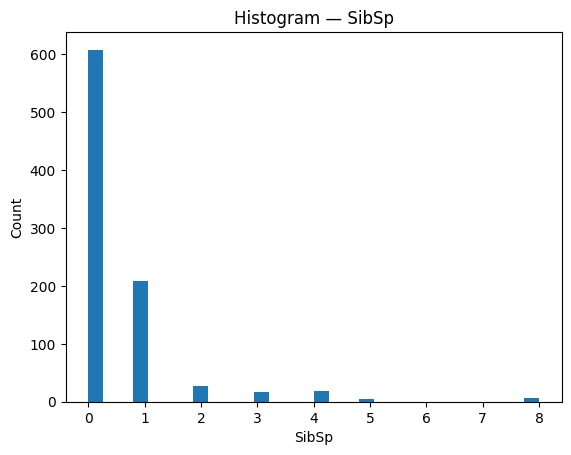

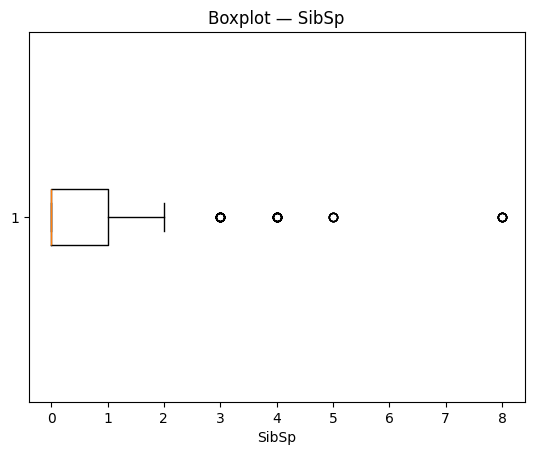

In [ ]:
# Histogram: SibSp
plt.figure()
plt.hist(df["SibSp"].dropna(), bins=30)
plt.title("Histogram — SibSp")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.show()

# Boxplot: SibSp
plt.figure()
plt.boxplot(df["SibSp"].dropna(), vert=False)
plt.title("Boxplot — SibSp")
plt.xlabel("SibSp")
plt.show()

### SibSp — Histogram & Boxplot
**Apa yang terlihat dari grafik:**
- Mayoritas nilai `SibSp` adalah 0 atau 1 (banyak yang tidak membawa saudara/pasangan).
- Ada nilai yang jarang (mis. 3,4,5 hingga 8) yang terlihat sebagai outlier.

**Interpretasi singkat:**
- Ini fitur berbentuk **count** (bilangan bulat), jadi “outlier” di sini bukan berarti salah, tapi hanya **jarang**.
- Nilai jarang bisa menyebabkan model overfit pada pola yang terlalu spesifik.

✅ **Keputusan Preprocessing Tahap 2:**
- **Tidak winsorize/drop** `SibSp` (karena count valid).
- Buat fitur yang lebih bermakna:
  - **Feature Engineering:** `FamilySize = SibSp + Parch + 1`
  - **IsAlone = (FamilySize == 1)**

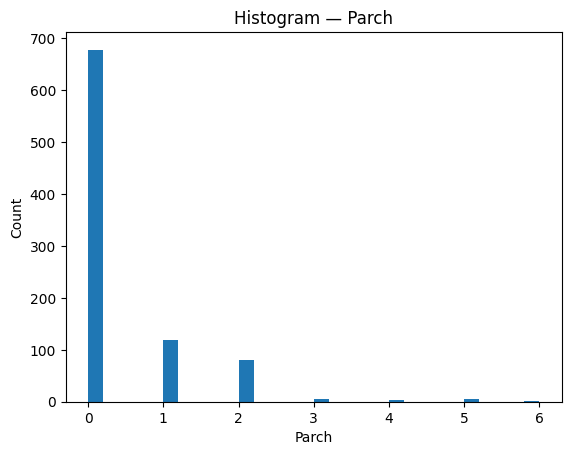

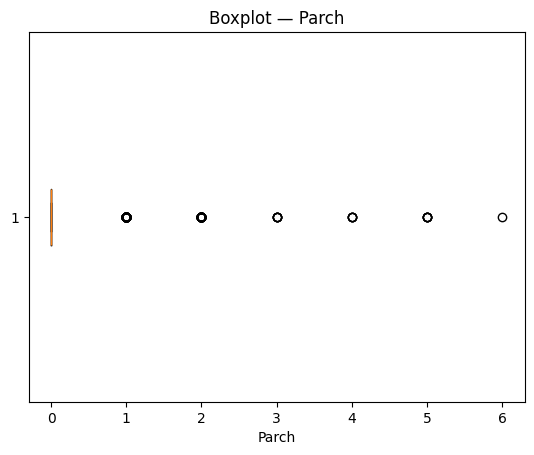

In [ ]:
# Histogram: Parch
plt.figure()
plt.hist(df["Parch"].dropna(), bins=30)
plt.title("Histogram — Parch")
plt.xlabel("Parch")
plt.ylabel("Count")
plt.show()

# Boxplot: Parch
plt.figure()
plt.boxplot(df["Parch"].dropna(), vert=False)
plt.title("Boxplot — Parch")
plt.xlabel("Parch")
plt.show()

### Parch — Histogram & Boxplot
**Apa yang terlihat dari grafik:**
- Mayoritas `Parch` bernilai 0 (banyak penumpang tanpa orang tua/anak).
- Nilai 1–6 muncul sangat sedikit dan terlihat sebagai outlier di boxplot.

**Interpretasi singkat:**
- Sama seperti `SibSp`, ini adalah fitur **count** yang outlier-nya cenderung valid.
- Nilai jarang lebih baik ditangani dengan *feature engineering* daripada “dipotong”.

✅ **Keputusan Preprocessing Tahap 2:**
- **Tidak winsorize/drop** `Parch`.
- Gabungkan dengan `SibSp` menjadi fitur yang lebih informatif:
  - `FamilySize` dan `IsAlone` (sama seperti di atas).



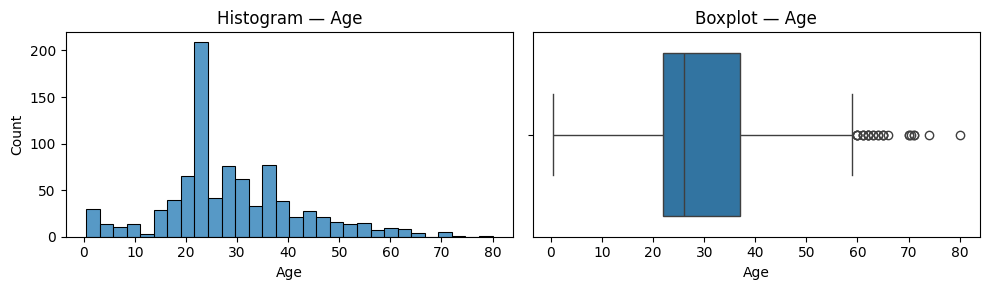

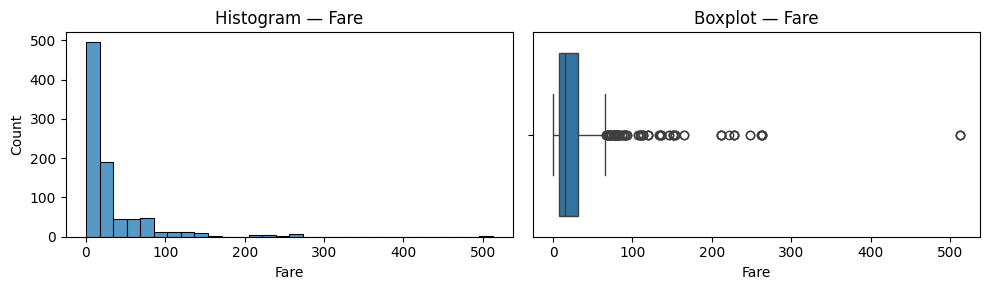

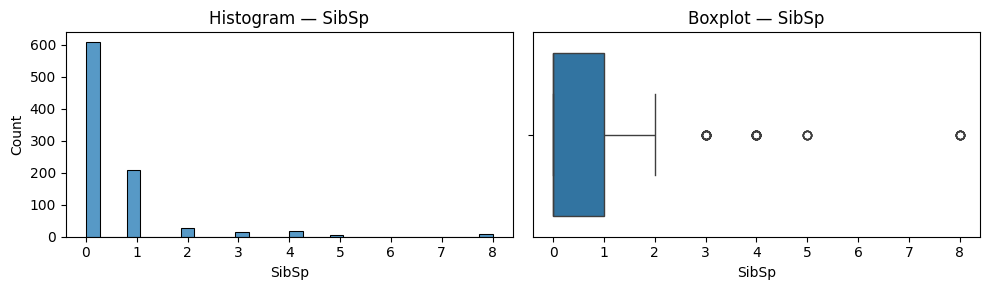

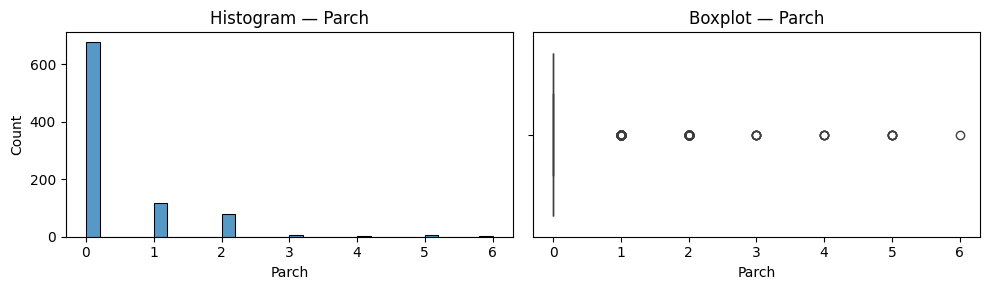

In [ ]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col].dropna(), bins=30, ax=axes[0])
    axes[0].set_title(f"Histogram — {col}")

    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f"Boxplot — {col}")

    plt.tight_layout()
    plt.show()

## Univariate - Kategorikal

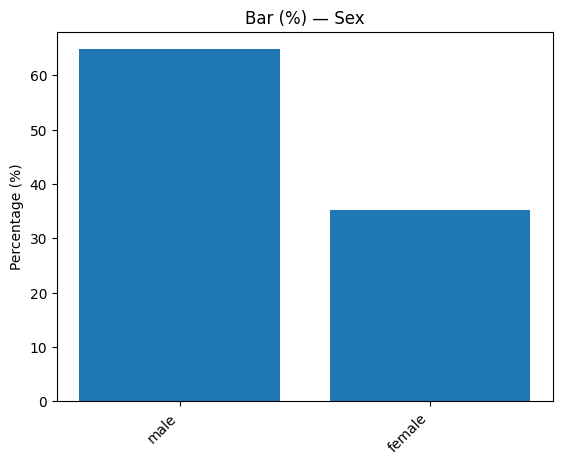

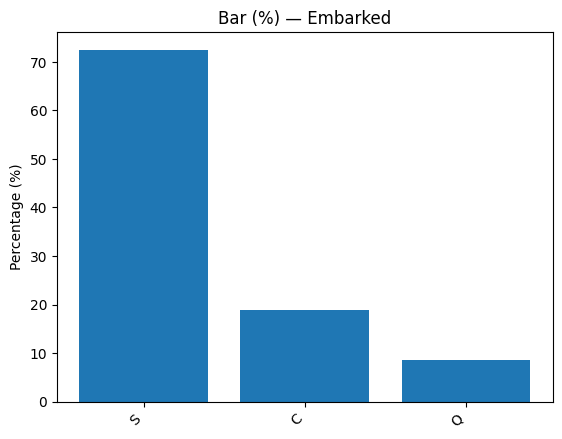

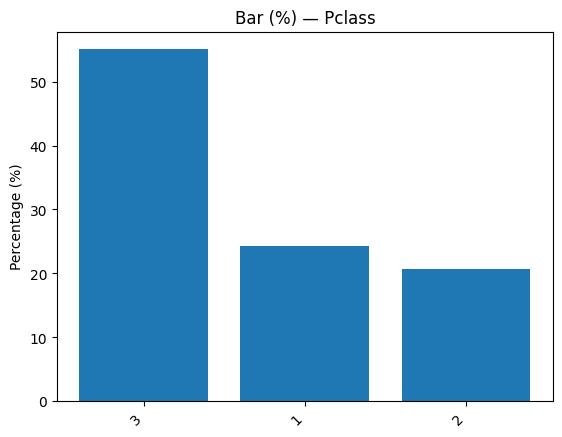

In [ ]:
def bar_pct(series, title):
    vc = series.value_counts(dropna=False)
    pct = (vc / len(series) * 100).round(2)
    plt.figure()
    plt.bar(vc.index.astype(str), pct.values)
    plt.title(title)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.show()

bar_pct(df["Sex"], "Bar (%) — Sex")
bar_pct(df["Embarked"], "Bar (%) — Embarked")
bar_pct(df["Pclass"], "Bar (%) — Pclass")

### Sex — Bar (%)
**Apa yang terlihat dari grafik:**
- Proporsi `male` lebih besar daripada `female` (dataset tidak seimbang antar gender).

**Interpretasi singkat:**
- Ketidakseimbangan ini bukan “error”, tapi penting untuk dipahami karena bisa memengaruhi analisis segmentasi dan hasil model.

✅ **Keputusan Preprocessing Tahap 2:**
- Lakukan **encoding**:
  - karena kategori sedikit (2 kelas) → **one-hot encoding** (atau mapping 0/1).
- Saat evaluasi model (opsional):
  - pastikan split mempertimbangkan target (stratify by `Survived`), bukan perlu stratify by `Sex`.



### Embarked — Bar (%)
**Apa yang terlihat dari grafik:**
- `S` dominan, disusul `C`, lalu `Q` paling sedikit.

**Interpretasi singkat:**
- Label `Embarked` sedikit (3 kategori) → cocok untuk one-hot.
- Karena ada kategori minor (`Q`), di dataset lain bisa berpotensi jadi *rare category* (di Titanic masih aman karena cuma 3 kategori).

✅ **Keputusan Preprocessing Tahap 2:**
- **One-hot encoding** untuk `Embarked`.
- (Opsional) kalau kategori minor terlalu kecil di dataset lain:
  - gabungkan ke `"Other"` sebelum one-hot (tidak wajib untuk Titanic).



### Pclass — Bar (%)
**Apa yang terlihat dari grafik:**
- `Pclass=3` paling banyak, kemudian `Pclass=1`, lalu `Pclass=2`.

**Interpretasi singkat:**
- Ini memberi konteks bahwa sebagian besar penumpang berasal dari kelas 3 (ekonomi), sehingga pola (Fare, survival) kemungkinan kuat dipengaruhi `Pclass`.

✅ **Keputusan Preprocessing Tahap 2:**
- Tentukan strategi encoding `Pclass` (pilih salah satu):
  1) **Ordinal encoding** (1 < 2 < 3) karena ada urutan kelas  
  2) **One-hot encoding** jika ingin model tidak mengasumsikan jarak linear antar kelas


## Bivariate - Numerikal VS Numerikal

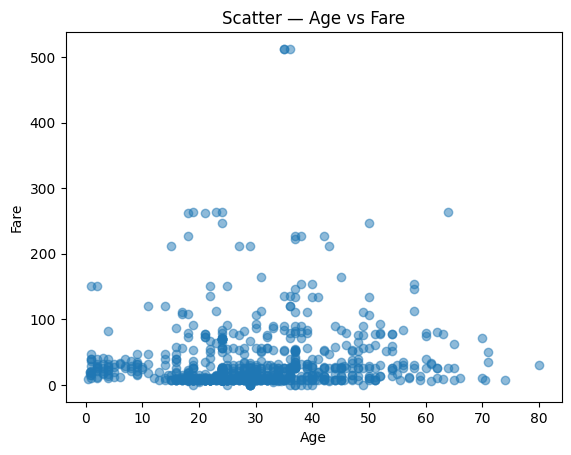

In [ ]:
# Scatter: Age vs Fare
plt.figure()
plt.scatter(df["Age"], df["Fare"], alpha=0.5)
plt.title("Scatter — Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Scatter Plot — Age vs Fare
**Apa yang terlihat dari grafik:**
- Titik-titik menyebar tanpa pola linear yang kuat antara `Age` dan `Fare`.
- Banyak data `Fare` berada di nilai rendah, tapi ada beberapa titik `Fare` sangat tinggi (outlier ekstrem).
- Outlier `Fare` muncul di berbagai usia (bukan hanya usia tertentu).

**Interpretasi singkat:**
- `Age` tidak punya hubungan langsung yang kuat dengan `Fare` (paling hanya indikasi lemah).
- Variabel `Fare` heavy-tail → perlu ditangani agar tidak mendominasi pembelajaran model.

✅ **Keputusan Preprocessing Tahap 2:**
- Untuk `Fare`:
  - Terapkan **log transform (`log1p`)** untuk mengurangi heavy-tail,
  - (opsional) **winsorize/cap p99** jika masih ada nilai ekstrem yang terlalu dominan.
- Untuk `Age`:
  - Tidak wajib transform khusus dari plot ini,

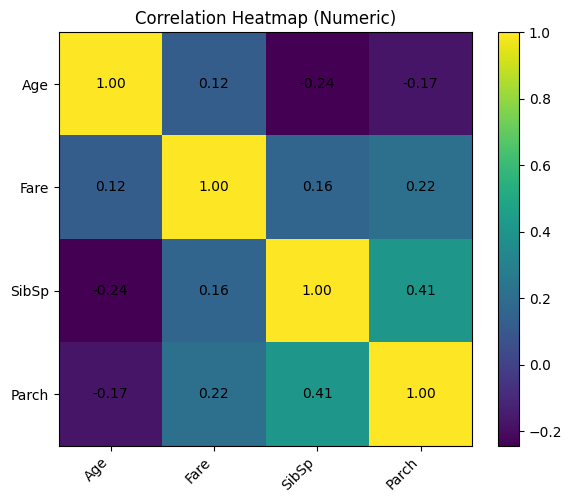

In [ ]:
num_for_corr = ["Age", "Fare", "SibSp", "Parch"]
corr = df[num_for_corr].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
plt.imshow(corr.values)
plt.title("Correlation Heatmap (Numeric)")

plt.xticks(range(len(num_for_corr)), num_for_corr, rotation=45, ha="right")
plt.yticks(range(len(num_for_corr)), num_for_corr)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.values[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Correlation Heatmap (Numeric)
**Apa yang terlihat dari heatmap:**
- Korelasi `Age`–`Fare` sekitar **0.12** → sangat lemah.
- Korelasi `SibSp`–`Parch` sekitar **0.41** → sedang (masuk akal karena sama-sama terkait keluarga).
- Korelasi lain kecil (dekat 0), artinya sebagian besar fitur numerik relatif tidak redundant.

**Interpretasi singkat:**
- Heatmap menunjukkan korelasi sebagai **indikasi**, bukan sebab-akibat.
- `SibSp` dan `Parch` punya hubungan → bagus untuk digabung jadi fitur yang lebih informatif.

✅ **Keputusan Preprocessing Tahap 2:**
- Lakukan **feature engineering keluarga**:
  - `FamilySize = SibSp + Parch + 1`
  - `IsAlone = (FamilySize == 1)`
- Tidak perlu drop fitur karena belum ada korelasi yang sangat tinggi (mis. > 0.8).
- Scaling tetap dilakukan (terutama untuk model sensitif skala), tapi heatmap ini menekankan FE lebih penting untuk keluarga.

## Bivariate - Numerikal VS Kategorikal

/tmp/ipython-input-2183878253.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df["Pclass"].unique()))


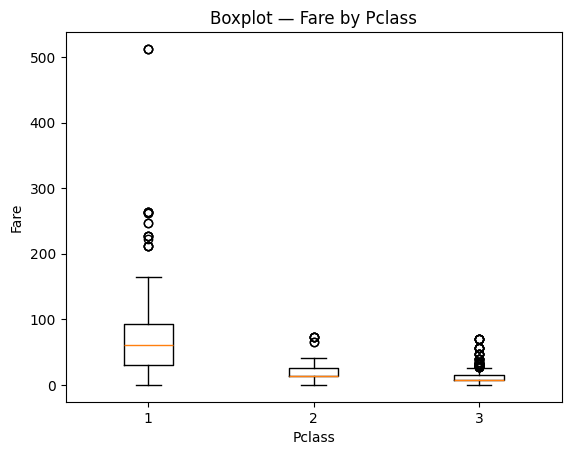

In [ ]:
groups = [df.loc[df["Pclass"] == c, "Fare"].dropna() for c in sorted(df["Pclass"].unique())]

plt.figure()
plt.boxplot(groups, labels=sorted(df["Pclass"].unique()))
plt.title("Boxplot — Fare by Pclass")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

### Boxplot — Fare by Pclass
**Apa yang terlihat dari grafik:**
- `Pclass=1` punya **median Fare paling tinggi** dan sebaran paling lebar.
- `Pclass=2` berada di tengah.
- `Pclass=3` punya **median Fare paling rendah**.
- Outlier `Fare` paling ekstrem banyak muncul di `Pclass=1` (masuk akal: tiket premium).

**Interpretasi singkat:**
- `Fare` bukan hanya “angka”, tapi sangat dipengaruhi oleh kelas penumpang (`Pclass`).
- Outlier Fare pada kelas 1 **kemungkinan valid** (bukan noise acak), jadi tidak ideal jika langsung di-drop.

✅ **Keputusan Preprocessing Tahap 2:**
1) **Skewness fix untuk Fare**:
   - Terapkan `Fare_log = log1p(Fare)` agar perbedaan ekstrem antar kelas lebih stabil.
2) **Outlier handling (opsional)**:
   - Jika masih terlalu ekstrem → lakukan **winsorize/cap p99** pada `Fare` (lebih aman daripada drop).
3) **Imputation yang lebih “nyambung konteks” (kalau Fare missing)**:
   - Isi `Fare` menggunakan **median per Pclass** (bukan median global), karena jelas berbeda antar kelas.
4) **Encoding untuk Pclass**:
   - Pclass tetap dipakai sebagai fitur penting → one-hot (aman) atau ordinal (kalau ingin mempertahankan urutan).


## Bivariate - Kategorikal VS Kategorikal

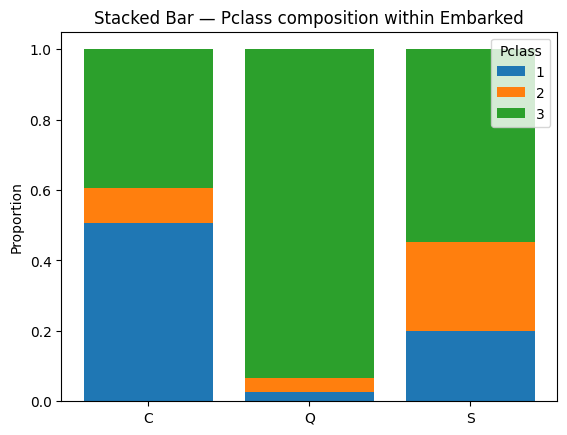

In [ ]:
ct = pd.crosstab(df["Embarked"], df["Pclass"], normalize="index")
plt.figure()
bottom = np.zeros(len(ct.index))
for col in ct.columns:
    plt.bar(ct.index.astype(str), ct[col].values, bottom=bottom, label=str(col))
    bottom += ct[col].values
plt.title("Stacked Bar — Pclass composition within Embarked")
plt.ylabel("Proportion")
plt.legend(title="Pclass")
plt.show()

### Stacked Bar — Pclass composition within Embarked
**Apa yang terlihat dari grafik:**
- Setiap pelabuhan keberangkatan (`Embarked`: C, Q, S) punya komposisi kelas (`Pclass`) yang berbeda.
- `Q` hampir didominasi oleh `Pclass=3` (penumpang kelas 3 sangat dominan).
- `C` terlihat punya proporsi `Pclass=1` lebih besar dibanding `S` dan `Q`.
- `S` cenderung campuran, tapi `Pclass=3` masih paling besar.

**Interpretasi singkat:**
- `Embarked` dan `Pclass` tidak independen — ada segmentasi sosial/ekonomi yang “nempel” di pelabuhan.
- Ini memberi sinyal bahwa kombinasi fitur kategori bisa membawa informasi lebih kuat daripada masing-masing sendiri.

✅ **Keputusan Preprocessing Tahap 2:**
- `Embarked` dan `Pclass` tetap dipakai sebagai fitur penting → lakukan **encoding** (one-hot / ordinal untuk Pclass).

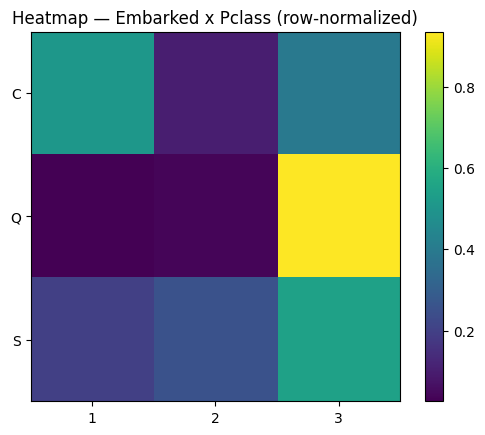

In [ ]:
plt.figure()
plt.imshow(ct.values)
plt.title("Heatmap — Embarked x Pclass (row-normalized)")
plt.xticks(range(len(ct.columns)), [str(c) for c in ct.columns])
plt.yticks(range(len(ct.index)), ct.index.astype(str))
plt.colorbar()
plt.show()

### Heatmap — Embarked × Pclass (row-normalized)
**Apa yang terlihat dari grafik:**
- Heatmap menegaskan pola yang sama dengan stacked bar, tapi lebih mudah “dibaca cepat”.
- Baris menunjukkan `Embarked`, kolom menunjukkan `Pclass`, nilai adalah proporsi per `Embarked`.

**Interpretasi singkat:**
- Heatmap (row-normalized) membantu memastikan bahwa perbedaan komposisi bukan karena jumlah total, tapi karena proporsi dalam tiap kategori.

✅ **Keputusan Preprocessing Tahap 2:**
- Karena ada pola kuat (contoh: Q ≈ dominan Pclass 3), fitur gabungan bisa meningkatkan sinyal (opsional).
- Tidak perlu merge rare category (karena `Embarked` hanya 3 kategori), cukup konsistenkan label + one-hot.
- Saat split data untuk training, pastikan tidak ada kategori yang hilang di test (solusi praktis: `handle_unknown="ignore"` saat one-hot di sklearn).

## Multivariate

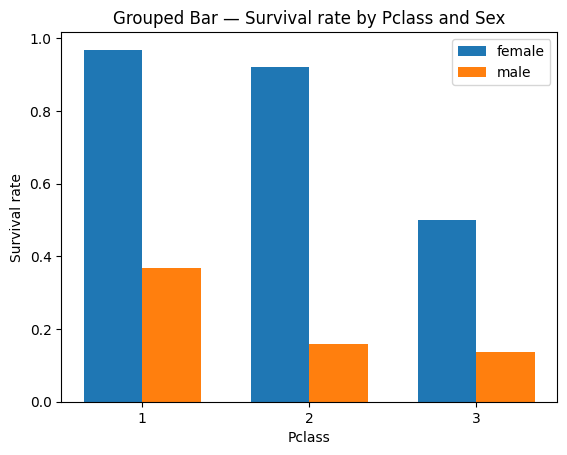

In [ ]:
rate = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
x = np.arange(len(rate.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, rate["female"], width, label="female")
plt.bar(x + width/2, rate["male"], width, label="male")
plt.xticks(x, rate.index.astype(str))
plt.title("Grouped Bar — Survival rate by Pclass and Sex")
plt.xlabel("Pclass")
plt.ylabel("Survival rate")
plt.legend()
plt.show()

### Grouped Bar — Survival rate by Pclass and Sex
**Apa yang terlihat dari grafik:**
- Di semua kelas (`Pclass` 1, 2, 3), **female selalu punya survival rate lebih tinggi** dibanding male.
- `Pclass=1` memiliki survival rate paling tinggi (terutama untuk female).
- `Pclass=3` paling rendah, terutama untuk male.

**Interpretasi singkat:**
- Ada pola kuat: survival dipengaruhi oleh **Sex** dan **Pclass**, dan efeknya konsisten.
- Ini menandakan `Sex` dan `Pclass` adalah fitur kategorikal yang sangat informatif.

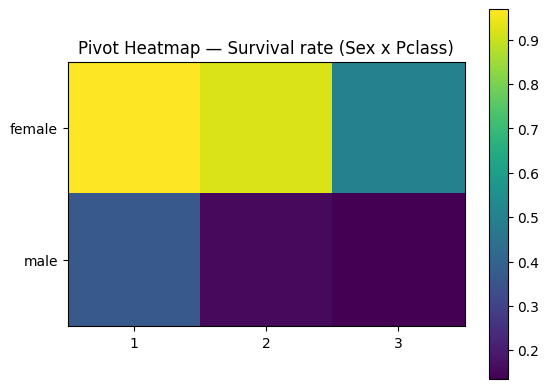

In [ ]:
pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
plt.figure()
plt.imshow(pivot.values)
plt.title("Pivot Heatmap — Survival rate (Sex x Pclass)")
plt.xticks(range(len(pivot.columns)), pivot.columns.astype(str))
plt.yticks(range(len(pivot.index)), pivot.index.astype(str))
plt.colorbar()
plt.show()

### Pivot Heatmap — Survival rate (Sex × Pclass)
**Apa yang terlihat dari heatmap:**
- Sel dengan nilai paling tinggi berada pada **female, Pclass=1**.
- Sel dengan nilai paling rendah berada pada **male, Pclass=3**.
- Heatmap membuat pola “ranking” kelompok lebih cepat terlihat dibanding bar chart.

**Interpretasi singkat:**
- Kombinasi `Sex × Pclass` punya sinyal prediktif tinggi terhadap target.
- Ini contoh kuat kenapa multivariate EDA penting: pola bisa lebih jelas ketika variabel digabungkan.


# Pre-processing Stage 2

## Skewness Fix

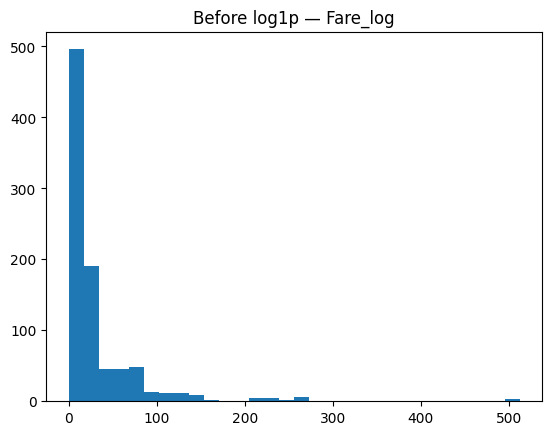

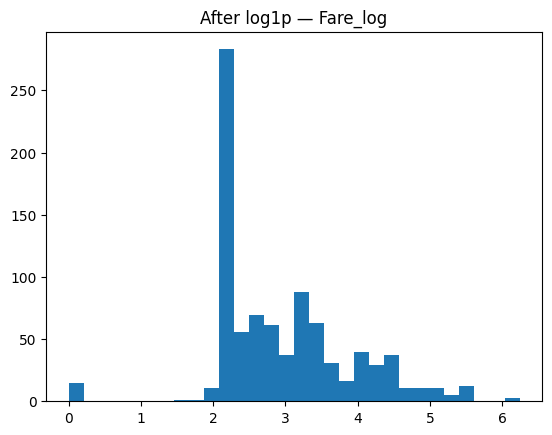

In [ ]:
df["Fare_log"] = np.log1p(df["Fare"])

plt.figure()
plt.hist(df["Fare"].dropna(), bins=30)
plt.title("Before log1p — Fare_log")
plt.show()


plt.figure()
plt.hist(df["Fare_log"].dropna(), bins=30)
plt.title("After log1p — Fare_log")
plt.show()

Dari EDA, `Fare` terlihat **sangat skew ke kanan** (banyak nilai kecil, sedikit nilai sangat besar).  
Agar distribusi lebih “stabil” dan tidak didominasi ekor panjang, kita lakukan transformasi:

- `Fare_log = log1p(Fare)` → aman untuk nilai 0 (karena log(1+0)=0)

**Yang dibandingkan pada plot:**
- **Before:** histogram `Fare` asli (biasanya heavy-tail / ekor panjang)
- **After:** histogram `Fare_log` (lebih rapat dan tidak terlalu ekstrem)


## Outlier Handling

### Drop Invalid

In [ ]:
valid_mask = (
    (df["Fare"].isna() | (df["Fare"] >= 0)) &
    (df["Age"].isna()  | ((df["Age"] >= 0) & (df["Age"] <= 100))) &
    (df["SibSp"] >= 0) &
    (df["Parch"] >= 0)
)

before_n = len(df)
df = df.loc[valid_mask].copy()
print("Dropped invalid rows:", before_n - len(df))

Dropped invalid rows: 0


Berdasarkan EDA, kita membedakan **invalid** vs **outlier**:

- **Invalid** = nilai mustahil / melanggar aturan dasar (contoh: Fare negatif, Age negatif)
- **Outlier** = nilai ekstrem tapi masih mungkin terjadi (contoh: Fare sangat tinggi di Pclass 1)

✅ Keputusan:
- Kita **drop** baris yang melanggar aturan dasar (invalid) karena ini cenderung error input.
- Kita **tidak** drop outlier Fare/Age hanya karena ekstrem, karena dari EDA terlihat outlier tersebut banyak yang valid.

### Winsorize (cap p1-p99)

In [ ]:
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    s_non = s.dropna()
    L = s_non.quantile(lower_q)
    U = s_non.quantile(upper_q)
    return s.clip(lower=L, upper=U), L, U

df["Fare_w"], L, U = winsorize_series(df["Fare_log"], 0.01, 0.99)
print("Fare winsorize bounds:", L, U)

Fare winsorize bounds: 0.0 5.5213317770348525


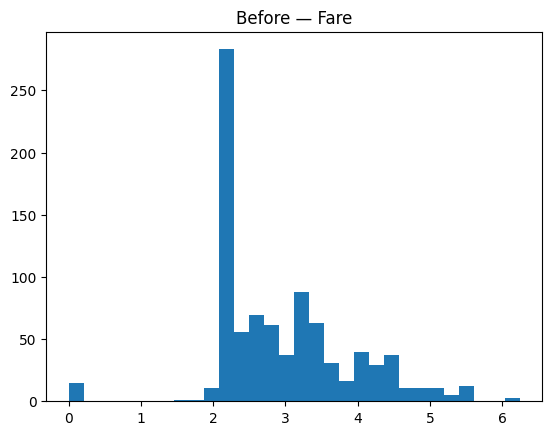

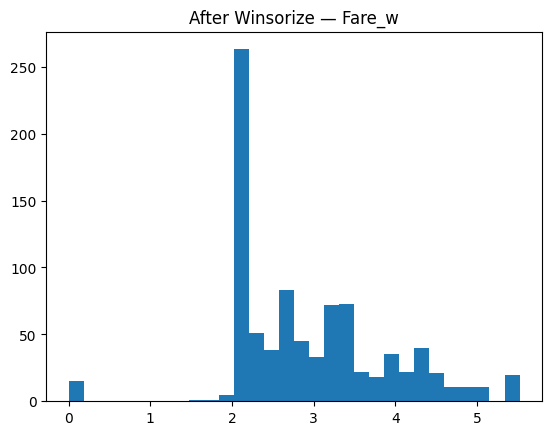

In [ ]:
plt.figure()
plt.hist(df["Fare_log"].dropna(), bins=30)
plt.title("Before — Fare")
plt.show()

plt.figure()
plt.hist(df["Fare_w"].dropna(), bins=30)
plt.title("After Winsorize — Fare_w")
plt.show()

Dari EDA:
- `Fare` sangat **skew ke kanan** dan banyak nilai ekstrem.
- Boxplot Fare by Pclass menunjukkan outlier terbesar banyak muncul di **Pclass 1** → kemungkinan besar **valid**, bukan error.

✅ Keputusan:
1) Kita lakukan **log transform**: `Fare_log = log1p(Fare)` untuk mengurangi heavy-tail.
2) Setelah log, jika masih ada ekstrem yang terlalu dominan, kita lakukan **winsorize** (cap p1–p99) pada `Fare_log`.

**Kenapa urutan ini?**
- `log1p` menangani masalah utama: bentuk distribusi yang miring (skewness).
- winsorize dipakai sebagai “pengaman” agar nilai ekstrem tidak mendominasi, tanpa membuang baris data.

## Feature Engineering (Optional)

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


df["CabinKnown"] = (df["Cabin"] != "Unknown").astype(int)
df["Deck"] = df["Cabin"].astype(str).str[0].replace({"U":"U"})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_log,Fare_w,FamilySize,IsAlone,CabinKnown,Deck
0,1,0,3,"braund, mr. owen harris",male,22.0,1,0,a/5 21171,7.2500,UNKNOWN,S,2.110213,2.110213,2,0,1,U
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1,0,pc 17599,71.2833,C85,C,4.280593,4.280593,2,0,1,C
2,3,1,3,"heikkinen, miss. laina",female,26.0,0,0,ston/o2. 3101282,7.9250,UNKNOWN,S,2.188856,2.188856,1,1,1,U
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834,3.990834,2,0,1,C
4,5,0,3,"allen, mr. william henry",male,35.0,0,0,373450,8.0500,UNKNOWN,S,2.202765,2.202765,1,1,1,U


In [ ]:
df['Deck'].value_counts()

,count
Deck,
U,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


### FamilySize & IsAlone
Dari EDA numerik (`SibSp` dan `Parch`):
- Nilai besar jarang (terlihat seperti outlier), tapi **valid** karena ini fitur count.
- Daripada memotong nilainya, lebih bagus kita ubah menjadi konsep yang lebih mudah dipelajari model.

✅ Keputusan:
- Buat `FamilySize` untuk menangkap “ukuran keluarga” dalam satu angka.
- Buat `IsAlone` untuk menangkap pola “sendirian vs tidak”.

**Output yang diharapkan:**
- Model lebih mudah menangkap pola survival terkait “sendiri” atau “bersama keluarga”
- Mengurangi noise dari nilai count yang jarang


### CabinKnown & Deck
Dari data kategorikal, `Cabin` banyak missing dan sudah kita isi `"Unknown"`.
Missing pada `Cabin` bisa jadi sinyal (misalnya penumpang kelas bawah lebih sering tidak punya data kabin).

✅ Keputusan:
- `CabinKnown`: indikator apakah kabin diketahui (1) atau tidak (0)
- `Deck`: mengambil huruf pertama kabin (mis. C85 → C) sebagai “deck”

## Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df_ord2 = df.copy()

enc = OrdinalEncoder(categories=[[1, 2, 3]])
df_ord2[["Pclass_ord"]] = enc.fit_transform(df_ord2[["Pclass"]])

df_ord2[["Pclass", "Pclass_ord"]].head()


,Pclass,Pclass_ord
0,3,2.0
1,1,0.0
2,3,2.0
3,1,0.0
4,3,2.0


In [ ]:
cat_cols = ["Sex", "Embarked", "Pclass", "Deck"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()
df[['Sex_female']]

KeyError: "None of [Index(['Sex_female'], dtype='object')] are in the [columns]"

## Scaling

Berdasarkan EDA:
- `Age` punya outlier yang **valid** (lansia), jadi kita tidak drop/winsorize.
- Untuk menjaga skala `Age` tetap stabil tanpa “ketarik” outlier, kita gunakan **RobustScaler khusus untuk Age**.

Sementara fitur numerik lain (mis. `Fare_log`, `SibSp`, `Parch`, `FamilySize`) bisa pakai **StandardScaler** karena:
- outlier-nya tidak separah Age (atau sudah ditangani dengan transform seperti log1p untuk Fare),
- dan standardization membuat model lebih stabil.

In [ ]:
target = "Survived"

X = df.drop(columns=[target])
y = df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler

age_col = ["Age"]
robust = RobustScaler()

In [ ]:
other_num_cols = ["Fare_log", "SibSp", "Parch", "FamilySize"]
standard = StandardScaler()

In [ ]:
print("Before:")
print(X_train[age_col + other_num_cols].head())

X_train[age_col] = robust.fit_transform(X_train[age_col])
X_test[age_col]  = robust.transform(X_test[age_col])

X_train[other_num_cols] = standard.fit_transform(X_train[other_num_cols])
X_test[other_num_cols]  = standard.transform(X_test[other_num_cols])

In [ ]:
print("\nAfter:")
print(X_train[age_col + other_num_cols].head())

### Kenapa scaling dilakukan setelah split?
Scaling harus **fit hanya pada data train** untuk menghindari **data leakage**.

✅ Prinsipnya:
- `fit_transform` → hanya untuk `X_train` (menghitung mean & std dari train)
- `transform` → untuk `X_test` (menggunakan mean & std yang sama dari train)
